In [1]:
#%pip install tslearn
#%pip install matplotlib

In [2]:
import csv

train_data = '../data/raw/sample_23.csv'
test_data = '../data/raw/sample_24.csv'

def extract_values(filepath):
    """Helper function to read a CSV and return a list of numerical rows."""
    data = []
    with open(filepath, mode='r') as file:
        csv_reader = csv.reader(file)
        headers = next(csv_reader)[1:]
        
        for row in csv_reader:
            numeric_row = [float(val) for val in row[1:]]
            data.append(numeric_row)
            
    return headers, data

# Extract data
headers_23, data_23 = extract_values(train_data)
headers_24, data_24 = extract_values(test_data)

total_absolute_error = 0.0
total_percentage_error = 0.0
total_data_points = 0
valid_mape_points = 0

for row_23, row_24 in zip(data_23, data_24):
    for val_23, val_24 in zip(row_23, row_24):
        
        total_absolute_error += abs(val_23 - val_24)
        total_data_points += 1
        
        # 2. Calculate percentage error for MAPE
        if val_24 != 0: 
            total_percentage_error += abs((val_24 - val_23) / val_24)
            valid_mape_points += 1

mae = total_absolute_error / total_data_points

if valid_mape_points > 0:
    mape = (total_percentage_error / valid_mape_points) * 100
else:
    mape = 0.0

print(f"Mean Absolute Error (MAE): {mae:.4f} units")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 3.8561 units
Mean Absolute Percentage Error (MAPE): 323.64%


In [3]:
import numpy as np
from tslearn.clustering import KShape
from tslearn.utils import to_time_series_dataset

data_array = np.array(data_23[:5000])
data_transposed = data_array.T

formatted_data = to_time_series_dataset(data_transposed)

ks = KShape(n_clusters=7, n_init=1, random_state=42)
ks.fit(formatted_data)

print(ks.cluster_centers_.shape)

/home/gopes/Documents/Clustering-And-Forecasting-TimeSeries-PlayingGround/venv/lib/python3.12/site-packages/tslearn/bases/bases.py:16: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


(7, 5000, 1)


In [4]:
import matplotlib.pyplot as plt

# inertias = []
# cluster_range = range(2, 10)

# for k in cluster_range:
    # model = KShape(n_clusters=k, n_init=1, random_state=42)
    # model.fit(formatted_data)
    # inertias.append(model.inertia_)

# plt.plot(cluster_range, inertias, marker='o')
# plt.title('Elbow Method For Optimal k')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia (Shape-Based Distance)')
# plt.show()

print(ks.inertia_)

0.09140742281983207


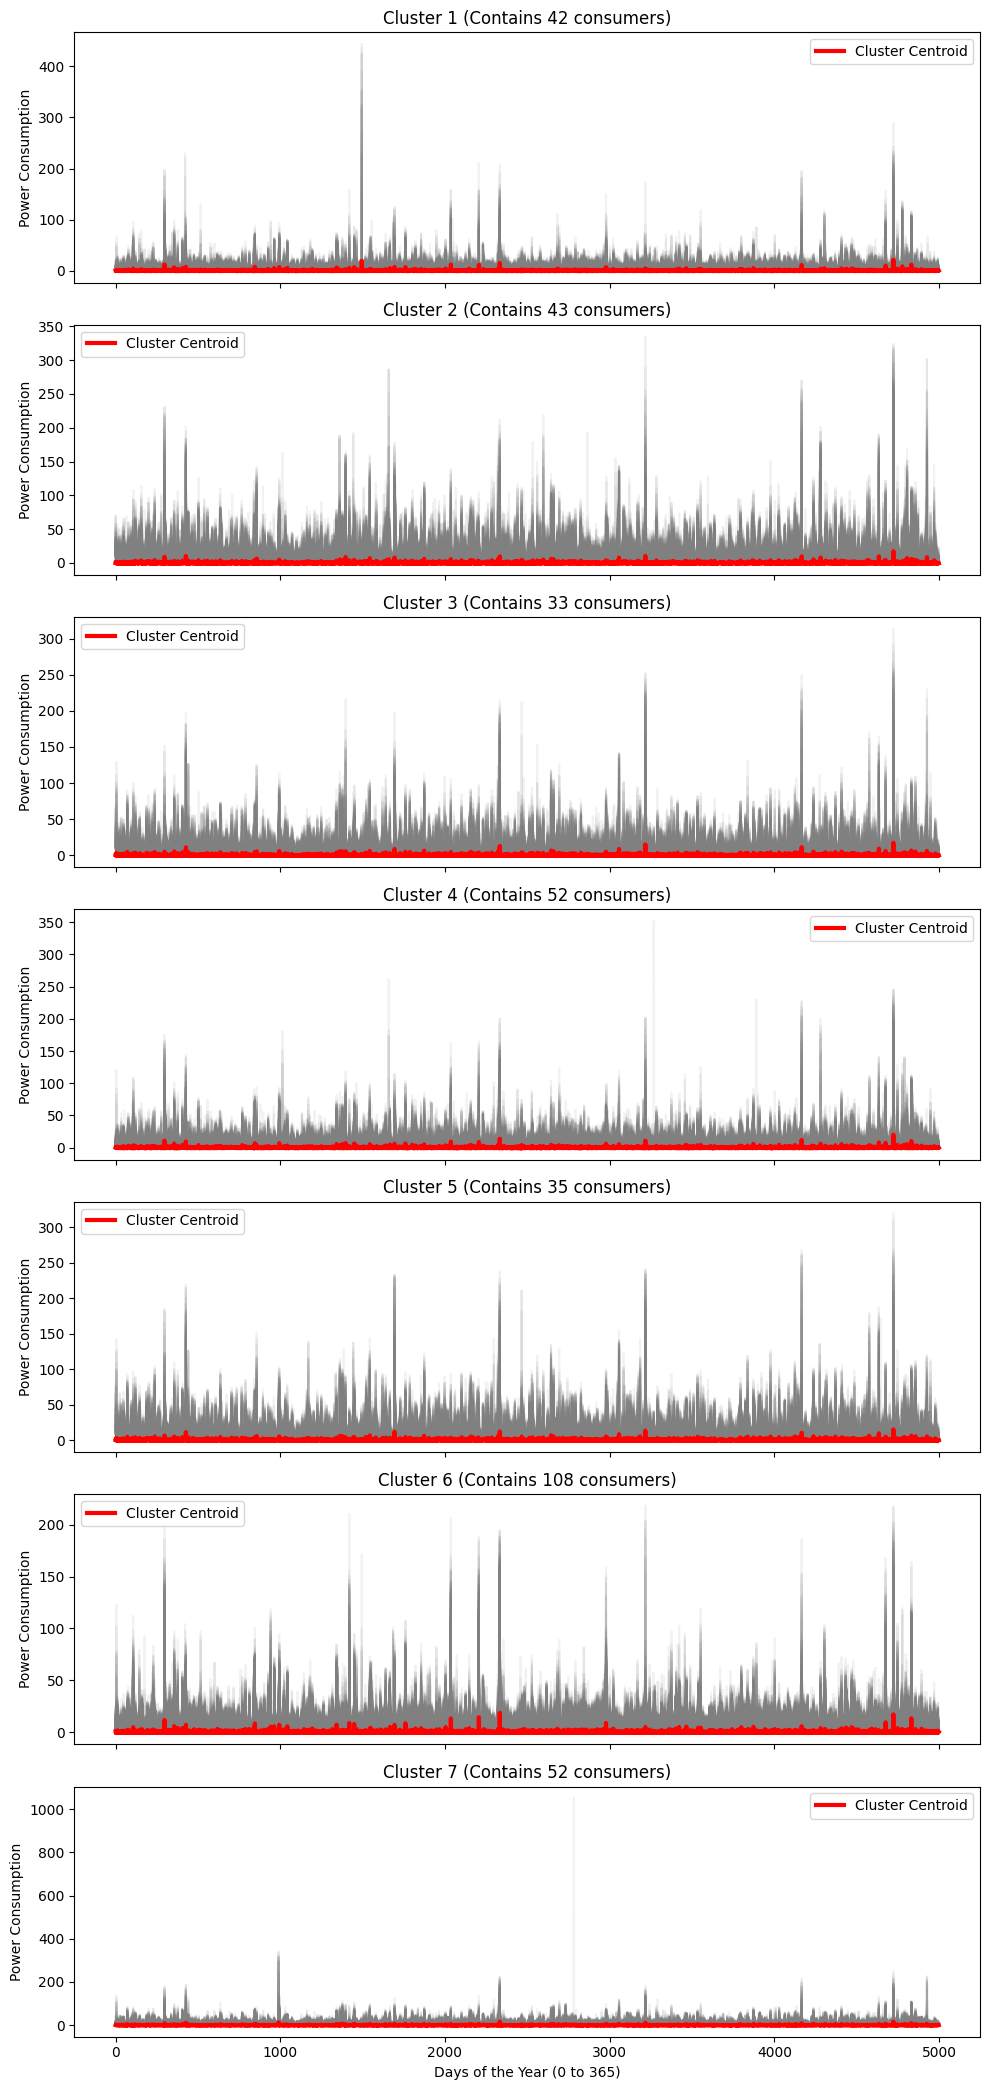

In [5]:
import matplotlib.pyplot as plt

labels = ks.labels_
centers = ks.cluster_centers_
optimal_k = len(centers)

# Set up a grid of plots, one row for each cluster
fig, axes = plt.subplots(optimal_k, 1, figsize=(10, 3 * optimal_k), sharex=True)

# Ensure axes is a list just in case k=1
if optimal_k == 1:
    axes = [axes]

for i in range(optimal_k):
    # Find all consumer data assigned to cluster 'i'
    cluster_data = formatted_data[labels == i]
    
    # 1. Plot all the individual consumers in this cluster
    # We use a low alpha (transparency) so they don't turn into a solid block of color
    for series in cluster_data:
        axes[i].plot(series.ravel(), color='gray', alpha=0.1)
        
    # 2. Plot the final cluster center (the generalized "shape") on top in bold
    axes[i].plot(centers[i].ravel(), color='red', linewidth=3, label='Cluster Centroid')
    
    # Format the subplot
    axes[i].set_title(f"Cluster {i+1} (Contains {len(cluster_data)} consumers)")
    axes[i].set_ylabel("Power Consumption")
    axes[i].legend()

# Format the overall figure
plt.xlabel("Days of the Year (0 to 365)")
plt.tight_layout() # Prevents labels from overlapping
plt.show()

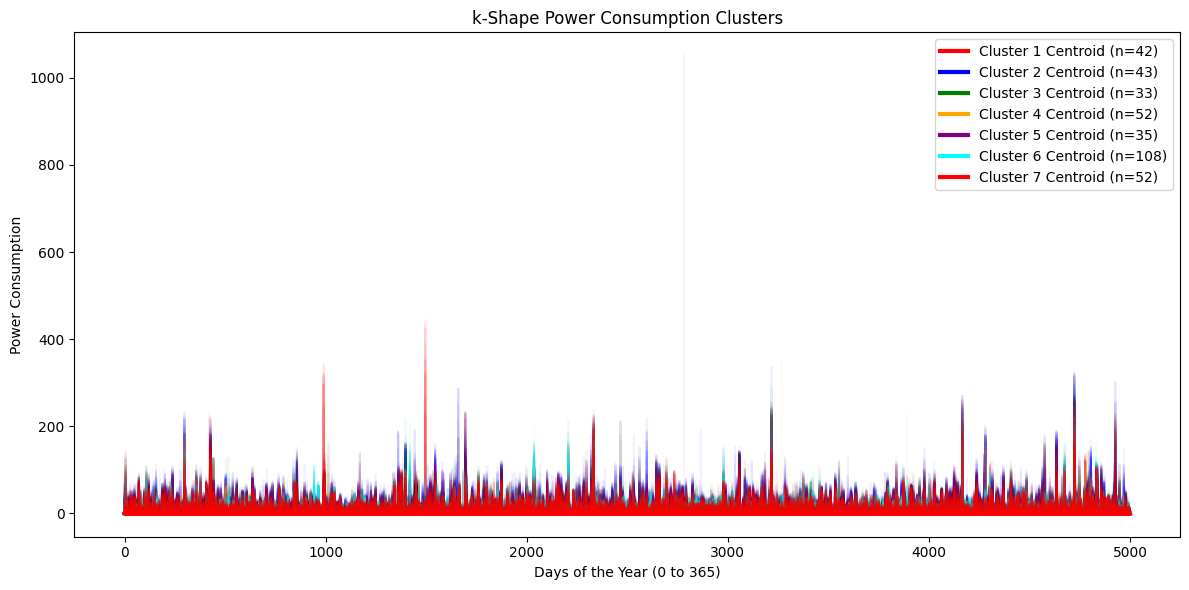

In [6]:
import matplotlib.pyplot as plt

labels = ks.labels_
centers = ks.cluster_centers_
optimal_k = len(centers)

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

# Set up a single, large plot
plt.figure(figsize=(12, 6))

for i in range(optimal_k):
    # Find all consumer data assigned to cluster 'i'
    cluster_data = formatted_data[labels == i]
    
    # Pick the color for this specific cluster
    cluster_color = colors[i % len(colors)]
    
    # 1. Plot all individual consumers in this cluster as a faint "cloud"
    # Alpha is very low (0.05) so the overlapping lines don't block everything out
    for series in cluster_data:
        plt.plot(series.ravel(), color=cluster_color, alpha=0.05)
        
    # 2. Plot the final cluster center (the generalized "shape") on top
    # We make it thick (linewidth=3) and fully opaque (alpha=1) so it stands out
    plt.plot(centers[i].ravel(), color=cluster_color, linewidth=3, 
             label=f'Cluster {i+1} Centroid (n={len(cluster_data)})')

# Format the overall figure
plt.title('k-Shape Power Consumption Clusters')
plt.xlabel('Days of the Year (0 to 365)')
plt.ylabel('Power Consumption')

# Add the legend (it will only pick up the centroids because they have 'label=' assigned)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()